In [1]:
# Getting relevant libraries
# VERIFY ALL INTENSIVE PHASES SUM TO ONE AND THAT THEY ARE NOT FORCED TO
import numpy as np 
import random
import matplotlib.pyplot as plt
import math
import pickle
import os
import pandas as pd
import random
plt.rcParams['figure.figsize'] = [10, 7]
from matplotlib.colors import LinearSegmentedColormap
#import mpl_scatter_density # adds projection='scatter_density'
from scipy.stats import gaussian_kde
from scipy import optimize
from molmass import Formula
import csv
import re
import copy
import gc
import time
import molmass as ms
from tqdm import tqdm

Coefficients [b0, b_Ca, b_T, b_Ca2, b_T2]:
[ 7.32261764e-01 -2.20453381e-02  1.47915640e-03 -1.60980560e-02
 -2.16492530e-07]
R^2: 0.99535


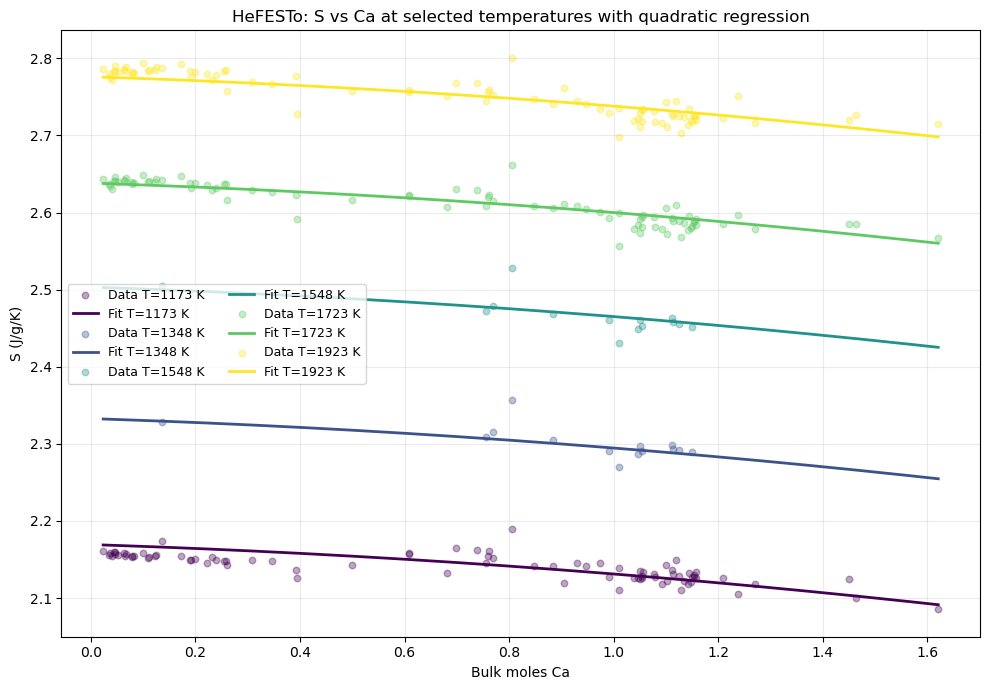

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg

# Load HeFESTo training data from the notebook directory
candidate_paths = [
    Path("HeFESTo_TrainsetMar2NTP.csv"),
    Path("notebooks") / "HeFESTo_TrainsetMar2NTP.csv",
]

for path in candidate_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("HeFESTo_TrainsetMar2NTP.csv not found in notebook directory.")

df = pd.read_csv(data_path)

# Target and predictors
s_col = "S(J/g/K)(System_main)"
t_col = "T(K)(System_main)"
ca_col = "Ca(Bulk_comp_elements)"

clean = df[[s_col, t_col, ca_col]].dropna().copy()
S = clean[s_col].to_numpy()
T = clean[t_col].to_numpy()
Ca = clean[ca_col].to_numpy()

# Design matrix with 5 columns: [1, Ca, T, Ca^2, T^2]
X = np.column_stack([
    np.ones_like(Ca),
    Ca,
    T,
    Ca**2,
    T**2,
])

# SciPy least-squares fit
coef, residuals, rank, singular_vals = linalg.lstsq(X, S)
print("Coefficients [b0, b_Ca, b_T, b_Ca2, b_T2]:")
print(coef)

S_hat = X @ coef
r2 = 1 - np.sum((S - S_hat) ** 2) / np.sum((S - np.mean(S)) ** 2)
print(f"R^2: {r2:.5f}")

# Choose 5 representative temperatures from the data range
unique_temps = np.sort(clean[t_col].unique())
target_temps = np.linspace(unique_temps.min(), unique_temps.max(), 5)
selected_temps = []
for t in target_temps:
    nearest = unique_temps[np.argmin(np.abs(unique_temps - t))]
    if nearest not in selected_temps:
        selected_temps.append(nearest)

# If deduplication produced fewer than 5, fill with evenly spaced unique temps
if len(selected_temps) < 5 and len(unique_temps) >= 5:
    idx = np.linspace(0, len(unique_temps) - 1, 5).astype(int)
    selected_temps = list(unique_temps[idx])

cmap = plt.cm.viridis(np.linspace(0, 1, len(selected_temps)))
plt.figure(figsize=(10, 7))

ca_min, ca_max = Ca.min(), Ca.max()
ca_grid = np.linspace(ca_min, ca_max, 200)

for color, temp in zip(cmap, selected_temps):
    subset = clean[clean[t_col] == temp]
    plt.scatter(
        subset[ca_col],
        subset[s_col],
        color=color,
        alpha=0.35,
        s=22,
        label=f"Data T={temp:.0f} K",
    )

    X_pred = np.column_stack([
        np.ones_like(ca_grid),
        ca_grid,
        np.full_like(ca_grid, temp),
        ca_grid**2,
        np.full_like(ca_grid, temp**2),
    ])
    S_pred = X_pred @ coef

    plt.plot(
        ca_grid,
        S_pred,
        color=color,
        linewidth=2,
        label=f"Fit T={temp:.0f} K",
    )

plt.xlabel("Bulk moles Ca")
plt.ylabel("S (J/g/K)")
plt.title("HeFESTo: S vs Ca at selected temperatures with quadratic regression")
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

def skewed_peak(x: np.ndarray, center: float, width: float, skew: float = 0, height: float = 1.0) -> np.ndarray:
    """
    Generate a skewed peak over x centered at `center`.

    Parameters
    ----------
    x : np.ndarray
        1D array of independent variable values.
    center : flo
        Location of the peak's maximum (mode).
    width : float
        Controls the width (standard deviation-like). Must be > 0.
    skew : float
        Skewness: 0 = symmetric, >0 = right-skewed, <0 = left-skewed.
    height : float
        Maximum height of the peak (default 1.0).

    Returns
    -------
    np.ndarray
        Peak-shaped array y(x) of same shape as input x.
    """
    if width <= 0:
        raise ValueError("width must be > 0")

    # Standardize x relative to peak center and width
    z = (x - center) / width

    # Use skew-normal PDF
    y = skewnorm.pdf(z, skew)
    
    # Normalize to specified height
    return np.array(height * y / y.max())

Coefficients [b0, b_Ca, b_T, b_Ca2, b_T2]:
[ 7.13174029e-01 -6.73611417e-02  1.31456994e-03  9.24570640e-03
 -1.74262002e-07]
R^2: 0.95945


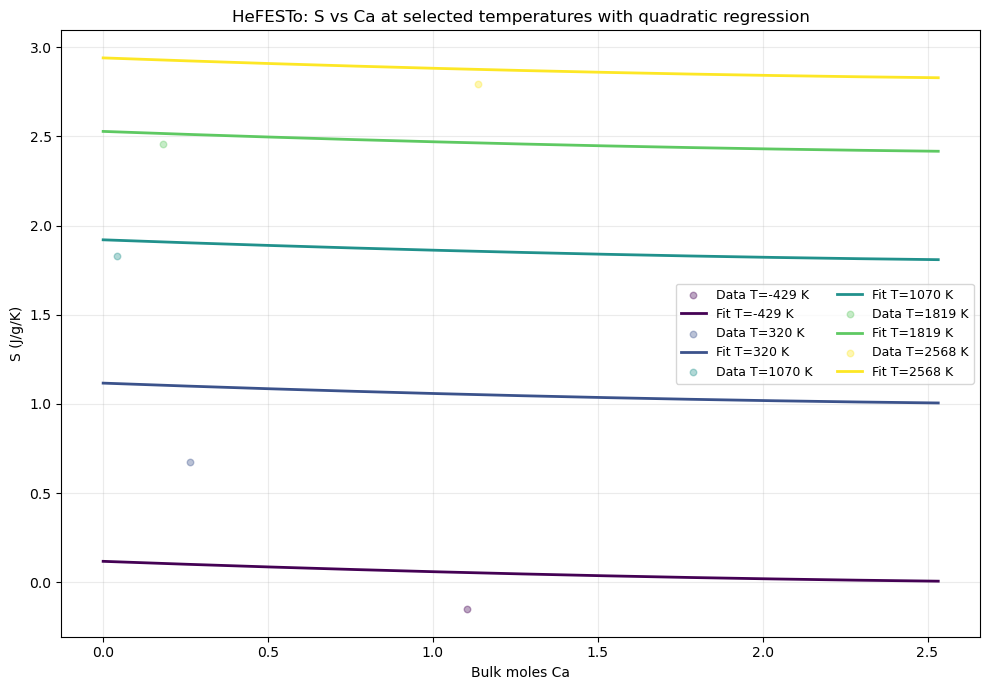

In [9]:
## FIT TO MARS



from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg

# Load HeFESTo training data from the notebook directory
candidate_paths = [
    Path("data/MELTStables/HeFESTo/Mars_profiles_phasechanges.csv"),
    Path("notebooks") / "Mars_profiles_phasechanges.csv",
    Path("Mars_profiles_phasechanges.csv"),
]

for path in candidate_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("HeFESTo_TrainsetMar2NTP.csv not found in notebook directory.")

df = pd.read_csv(data_path)

# Target and predictors
s_col = "S(J/g/K)(System_main)"
t_col = "T(K)(System_main)"
ca_col = "Ca(Bulk_comp_elements)"

clean = df[[s_col, t_col, ca_col]].dropna().copy()
in_range = (clean[s_col] > 1.75) & (clean[s_col] < 2.9)
S = clean[s_col].to_numpy()[in_range]
T = clean[t_col].to_numpy()[in_range]
Ca = clean[ca_col].to_numpy()[in_range]

# Design matrix with 5 columns: [1, Ca, T, Ca^2, T^2]
X = np.column_stack([
    np.ones_like(Ca),
    Ca,
    T,
    Ca**2,
    T**2,
])

# SciPy least-squares fit
coef, residuals, rank, singular_vals = linalg.lstsq(X, S)
print("Coefficients [b0, b_Ca, b_T, b_Ca2, b_T2]:")
print(coef)

S_hat = X @ coef
r2 = 1 - np.sum((S - S_hat) ** 2) / np.sum((S - np.mean(S)) ** 2)
print(f"R^2: {r2:.5f}")

# Choose 5 representative temperatures from the data range
unique_temps = np.sort(clean[t_col].unique())
target_temps = np.linspace(unique_temps.min(), unique_temps.max(), 5)
selected_temps = []
for t in target_temps:
    nearest = unique_temps[np.argmin(np.abs(unique_temps - t))]
    if nearest not in selected_temps:
        selected_temps.append(nearest)

# If deduplication produced fewer than 5, fill with evenly spaced unique temps
if len(selected_temps) < 5 and len(unique_temps) >= 5:
    idx = np.linspace(0, len(unique_temps) - 1, 5).astype(int)
    selected_temps = list(unique_temps[idx])

cmap = plt.cm.viridis(np.linspace(0, 1, len(selected_temps)))
plt.figure(figsize=(10, 7))

ca_min, ca_max = Ca.min(), Ca.max()
ca_grid = np.linspace(ca_min, ca_max, 200)

for color, temp in zip(cmap, selected_temps):
    subset = clean[clean[t_col] == temp]
    plt.scatter(
        subset[ca_col],
        subset[s_col],
        color=color,
        alpha=0.35,
        s=22,
        label=f"Data T={temp:.0f} K",
    )

    X_pred = np.column_stack([
        np.ones_like(ca_grid),
        ca_grid,
        np.full_like(ca_grid, temp),
        ca_grid**2,
        np.full_like(ca_grid, temp**2),
    ])
    S_pred = X_pred @ coef

    plt.plot(
        ca_grid,
        S_pred,
        color=color,
        linewidth=2,
        label=f"Fit T={temp:.0f} K",
    )

plt.xlabel("Bulk moles Ca")
plt.ylabel("S (J/g/K)")
plt.title("HeFESTo: S vs Ca at selected temperatures with quadratic regression")
plt.grid(alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

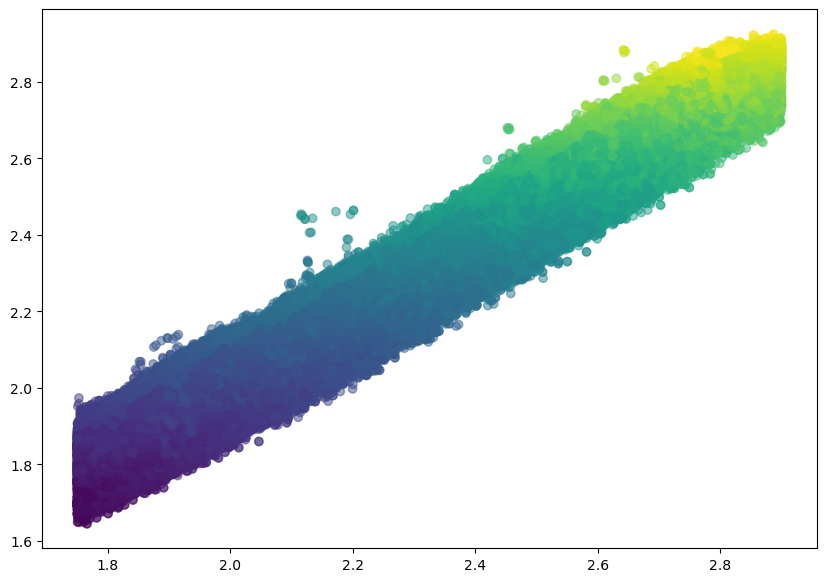

In [10]:
plt.scatter(S, S_hat, alpha = 0.5, c = T)